In [1]:
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.datasets import load_sample_images

sample_images = load_sample_images()['images']
sample_images = np.stack(sample_images)
sample_images = torch.FloatTensor(sample_images)
sample_images /= 255

In [3]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)

print(sample_images_permuted.dtype, sample_images_permuted.shape)

torch.float32 torch.Size([2, 3, 427, 640])


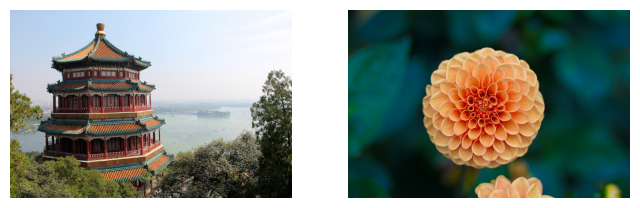

In [4]:
def plot_image(img_tensor):
    plt.imshow(img_tensor.permute(1,2,0))
    plt.axis('off')

plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [5]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [6]:
# ResNet50_Weights.IMAGENET1K_V2

In [7]:
import torch.hub
import urllib.request
import ssl
import torchvision

# Force PyTorch's downloader to use an unverified SSL context
unverified_context = ssl._create_unverified_context()
torch.hub.urlopen = lambda url, **kwargs: urllib.request.urlopen(
    url, context=unverified_context, **kwargs
)


weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights)
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=128, out_features=512, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=512, out_features=128, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(

In [8]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.mps.is_available():
    device = 'mps'
else: 
    device = 'cpu'

device

'mps'

In [9]:
len(weights.meta['categories'])

1000

In [10]:
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

In [11]:
# custom_transform = T.Compose([
#     T.Resize(232),
#     T.CenterCrop(224),
# ])
# preprocessed_images = custom_transform(sample_images_permuted)
# preprocessed_images.round(decimals=2)

In [12]:
transform = weights.transforms()
preprocessed_images = transform(sample_images_permuted)
preprocessed_images.shape

torch.Size([2, 3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0995362..2.6400006].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1390412].


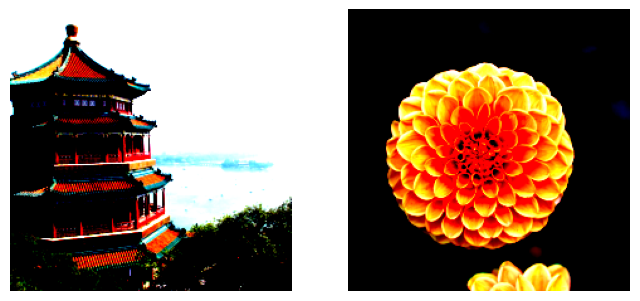

In [13]:
plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(preprocessed_images):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [14]:
with torch.inference_mode():
# with torch.no_grad():
    y_logit = model(preprocessed_images)

y_probas = y_logit.softmax(dim=1)
y_probas

tensor([[0.0008, 0.0002, 0.0003,  ..., 0.0004, 0.0005, 0.0003],
        [0.0003, 0.0004, 0.0002,  ..., 0.0007, 0.0143, 0.0005]])

In [15]:
y_preds = y_logit.argmax(dim=1)
y_preds = y_probas.argmax(dim=1)
y_preds

tensor([698, 985])

In [16]:
class_names = weights.meta['categories']
[class_names[cls_ind] for cls_ind in y_preds]

['palace', 'daisy']

In [17]:
y_top5_probas, y_top_indices = y_probas.topk(k=5, dim=1)
y_top5_probas, y_top_indices

(tensor([[0.3156, 0.1457, 0.0479, 0.0119, 0.0115],
         [0.2557, 0.0457, 0.0438, 0.0261, 0.0241]]),
 tensor([[698, 663, 975, 442, 449],
         [985, 599, 883, 716, 309]]))

In [18]:
y_top5_preds = [[class_names[ind] for ind in img_indices] for img_indices in y_top_indices]
y_top5_preds

[['palace', 'monastery', 'lakeside', 'bell cote', 'boathouse'],
 ['daisy', 'honeycomb', 'vase', 'picket fence', 'bee']]

# Transfer Learning (parameter tuning)

In [20]:
import ssl
import urllib.request

# Force the main urlopen call to always inject the unverified context
orig_urlopen = urllib.request.urlopen
urllib.request.urlopen = lambda *args, **kwargs: orig_urlopen(*args, context=ssl._create_unverified_context(), **kwargs)

import torchvision

transform = T.Compose([
    T.ToTensor(),
    T.CenterCrop(500),
])

flowers_to_display = torchvision.datasets.Flowers102(
	root="datasets",
	split="train",
	download=True,
	transform=transform,
)
flowers_to_display

100.0%
100.0%
100.0%


Dataset Flowers102
    Number of datapoints: 1020
    Root location: datasets
    split=train
    StandardTransform
Transform: Compose(
                 ToTensor()
                 CenterCrop(size=(500, 500))
           )

In [23]:
class_names = torchvision.datasets.Flowers102.classes

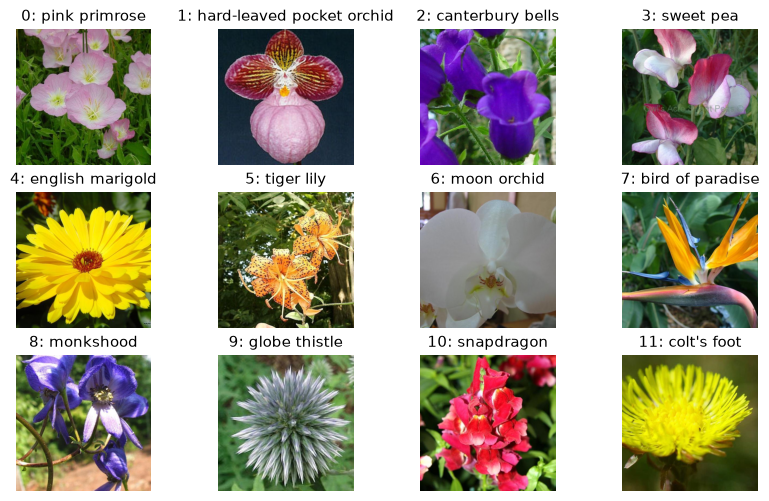

In [24]:
sample_flowers = sorted({y: img for img, y in flowers_to_display}.items())[:12]

plt.figure(figsize=(10, 6))
for class_id, image in sample_flowers:
	if class_id == 12: 
		break
	plt.subplot(3, 4, class_id + 1)
	plot_image(image)
	plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [33]:
from functools import partial

def topla(x,y):
    return x+y

topla_5le = partial(topla, x=5)

In [37]:
topla_5le(y=-5)

0

In [99]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
transforms = weights.transforms()
model = torchvision.models.resnet50(weights = weights).to(device)

In [100]:
DefaultFlowers102 = partial(
    torchvision.datasets.Flowers102,
    root="datasets",
    download=True,
    transform=transforms,
    )

train_set = DefaultFlowers102(split="train")
test_set = DefaultFlowers102(split="test")
valid_set = DefaultFlowers102(split="val")

In [101]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [102]:
next(iter(train_loader))[0].shape

torch.Size([32, 3, 224, 224])

In [103]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [104]:
[name for name, child in model.named_children()]

['conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1',
 'layer2',
 'layer3',
 'layer4',
 'avgpool',
 'fc']

In [105]:
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [106]:
n_classes = len(class_names)
model.fc = nn.Linear(in_features=2048, out_features=n_classes, bias=True).to(device)

In [107]:
model.fc

Linear(in_features=2048, out_features=102, bias=True)

In [108]:
for param in model.parameters():
    param.requires_grad = False

In [109]:
for param in model.fc.parameters():
    param.requires_grad = True

In [110]:
from custom_utils import train, plot_history

In [111]:
n_epochs = 10
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=n_classes).to(device)

history = train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device = device, 
    restore_best_parameters = False,
  )

Epoch: 1/10, Train Loss: 4.341, Train Metric: 0.141, Valid Metric: 0.548, Time: 16.34s
	Checkpoint, valid metric: 0.548
Epoch: 2/10, Train Loss: 3.042, Train Metric: 0.88, Valid Metric: 0.759, Time: 16.14s
	Checkpoint, valid metric: 0.759
Epoch: 3/10, Train Loss: 2.12, Train Metric: 0.978, Valid Metric: 0.802, Time: 15.91s
	Checkpoint, valid metric: 0.802
Epoch: 4/10, Train Loss: 1.472, Train Metric: 0.992, Valid Metric: 0.819, Time: 15.67s
	Checkpoint, valid metric: 0.819
Epoch: 5/10, Train Loss: 1.007, Train Metric: 1.0, Valid Metric: 0.833, Time: 15.1s
	Checkpoint, valid metric: 0.833
Epoch: 6/10, Train Loss: 0.755, Train Metric: 0.999, Valid Metric: 0.835, Time: 14.25s
	Checkpoint, valid metric: 0.835
Epoch: 7/10, Train Loss: 0.574, Train Metric: 0.999, Valid Metric: 0.846, Time: 14.43s
	Checkpoint, valid metric: 0.846
Epoch: 8/10, Train Loss: 0.435, Train Metric: 1.0, Valid Metric: 0.852, Time: 14.69s
	Checkpoint, valid metric: 0.852
Epoch: 9/10, Train Loss: 0.354, Train Metric: 1

In [112]:
history = train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device = device, 
    restore_best_parameters = False,
  )

Epoch: 1/10, Train Loss: 0.247, Train Metric: 1.0, Valid Metric: 0.852, Time: 15.74s
	Checkpoint, valid metric: 0.852
Epoch: 2/10, Train Loss: 0.203, Train Metric: 1.0, Valid Metric: 0.859, Time: 15.21s
	Checkpoint, valid metric: 0.859
Epoch: 3/10, Train Loss: 0.172, Train Metric: 1.0, Valid Metric: 0.855, Time: 15.8s
Epoch: 4/10, Train Loss: 0.144, Train Metric: 1.0, Valid Metric: 0.85, Time: 14.28s
Epoch: 5/10, Train Loss: 0.137, Train Metric: 1.0, Valid Metric: 0.852, Time: 13.7s
Epoch: 6/10, Train Loss: 0.114, Train Metric: 1.0, Valid Metric: 0.862, Time: 13.9s
	Checkpoint, valid metric: 0.862
Epoch: 7/10, Train Loss: 0.109, Train Metric: 1.0, Valid Metric: 0.859, Time: 13.59s
Epoch: 8/10, Train Loss: 0.099, Train Metric: 1.0, Valid Metric: 0.854, Time: 14.36s
Epoch: 9/10, Train Loss: 0.093, Train Metric: 1.0, Valid Metric: 0.854, Time: 14.23s
Epoch: 10/10, Train Loss: 0.078, Train Metric: 1.0, Valid Metric: 0.86, Time: 14.65s


In [88]:
for param in model.parameters():
    param.requires_grad = True

In [89]:
history = train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    valid_loader,
    15,
    device = device, 
    restore_best_parameters = True,
  )

Epoch: 1/5, Train Loss: 0.462, Train Metric: 0.879, Valid Metric: 0.717, Time: 32.5s
	Checkpoint, valid metric: 0.717
Epoch: 2/5, Train Loss: 0.139, Train Metric: 0.968, Valid Metric: 0.781, Time: 26.62s
	Checkpoint, valid metric: 0.781
Epoch: 3/5, Train Loss: 0.047, Train Metric: 0.988, Valid Metric: 0.811, Time: 27.3s
	Checkpoint, valid metric: 0.811
Epoch: 4/5, Train Loss: 0.036, Train Metric: 0.991, Valid Metric: 0.816, Time: 26.54s
	Checkpoint, valid metric: 0.816
Epoch: 5/5, Train Loss: 0.016, Train Metric: 0.997, Valid Metric: 0.818, Time: 26.87s
	Checkpoint, valid metric: 0.818
Restoring best parameters from epoch 5 with valid metric: 0.818
